# Env-Reward-Validation

Lightweight diagnostics to validate reward incentives, simulator regimes, and whether the learned policy reacts to sensible signals.

## 1. Load trained policy and generate trajectories

We run the greedy Dyna-Q policy for enough episodes to gather stable statistics and store the raw trajectory data in a DataFrame.

In [18]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))
sys.path.append(str(PROJECT_ROOT / "LLM-DynaQ"))

print(PROJECT_ROOT)

c:\Users\rayan\OneDrive\Bureau\RL-Based-LLM-Inference\dynamic k


In [19]:
from __future__ import annotations

from pathlib import Path
import math
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from decoding.speculative import HuggingFaceTreeSpeculativeDecoder
from llm_env import LLMTreeSpeculativeDecodingEnv
from prompt_dataset import PromptDataset
from state.features import featurize_state

plt.rcParams.update({"figure.dpi": 110})

In [20]:
# ---- Config ----
WORKLOAD_STYLE = "steady_low_load"
EPISODES = 20  # Reduced for validation since real LLM inference takes some time
EPISODE_LENGTH = 16
SEED = 42
DATASET_PATH = "hf://datasets/LLMs/Alpaca-ShareGPT/alpaca_sharedgpt_data.json"

prompt_dataset = PromptDataset.from_hf_json(
    DATASET_PATH, seed=SEED, max_prompts=EPISODES, sample_strategy="sequential"
)

decoder = HuggingFaceTreeSpeculativeDecoder(
    draft_model_name="distilgpt2",
    target_model_name="gpt2",
)

env = LLMTreeSpeculativeDecodingEnv(
    decoder=decoder,
    prompt_dataset=prompt_dataset,
    workload_style=WORKLOAD_STYLE,
    episode_length=EPISODE_LENGTH,
    seed=SEED,
)

FEATURE_NAMES = [
    "feat_last_k",
    "feat_last_acceptance_bucket",
    "feat_ema_acceptance_bucket",
    "feat_rejection_bucket",
    "feat_prompt_bucket",
    "feat_generated_bucket",
    "feat_queue_bucket",
    "feat_batch_bucket",
    "feat_arrival_bucket",
    "feat_load_bucket",
    "feat_sla_bucket",
    "feat_branching_bucket",
]

def bucket_acceptance(value: float) -> int:
    if value < 0.35:
        return 0
    if value < 0.65:
        return 1
    return 2

def bucket_load(value: float) -> int:
    if value < 0.35:
        return 0
    if value < 0.70:
        return 1
    return 2

def bucket_queue(value: int) -> int:
    if value <= 2:
        return 0
    if value <= 6:
        return 1
    return 2

def rolling_mean(series: pd.Series, window: int = 200) -> pd.Series:
    return series.rolling(window=window, min_periods=max(10, window // 5)).mean()

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 2113.07it/s]


In [21]:
records = []
episode_returns = []
episode_avg_k = []
global_step = 0

for episode in range(EPISODES):
    state = env.reset()
    total_reward = 0.0
    actions = []

    for step in range(EPISODE_LENGTH):
        # Baseline Policy: Pick a random K to explore the space uniformly
        action = random.randint(1, 6)
        
        next_state, reward, done, info = env.step(state, action)

        feature_state = featurize_state(state)
        records.append(
            {
                "episode": episode,
                "step": step,
                "global_step": global_step,
                "action": action,
                "reward": reward,
                "acceptance_rate": next_state["last_acceptance_rate"],
                "ema_acceptance": next_state["ema_acceptance_rate"],
                "system_load": next_state["system_load"],
                "queue_length": next_state["queue_length"],
                "sla_slack_ms": next_state["sla_slack_ms"],
                "normalized_tree_cost": info["normalized_tree_cost"],
                "accepted_tokens": info["accepted_tokens"],
                "rejected_depth": max(0, action - info["accepted_tokens"]),
                "emitted_tokens": info["emitted_tokens"],
                "feature_state": feature_state,
            }
        )

        total_reward += reward
        actions.append(action)
        global_step += 1
        state = next_state
        if done:
            break

    episode_returns.append(total_reward)
    episode_avg_k.append(float(np.mean(actions)) if actions else float("nan"))
    print(f"Finished episode {episode+1}/{EPISODES} | Reward: {total_reward:.2f}")

df = pd.DataFrame(records)
feat_df = pd.DataFrame(df["feature_state"].to_list(), columns=FEATURE_NAMES)
df = pd.concat([df, feat_df], axis=1)

df["acceptance_bucket"] = df["ema_acceptance"].apply(bucket_acceptance)
df["load_bucket"] = df["system_load"].apply(bucket_load)
df["queue_bucket"] = df["queue_length"].apply(bucket_queue)

episodes_df = pd.DataFrame({
    "episode": list(range(EPISODES)),
    "episode_return": episode_returns,
    "avg_k": episode_avg_k,
})

df.head()

[Env] Starting episode 1 with prompt length 34
      Episode 1 | Step 01/16 | K: 01 | Accepted: 01 | Cost: 1.585
      Episode 1 | Step 02/16 | K: 06 | Accepted: 04 | Cost: 4.524
      Episode 1 | Step 03/16 | K: 02 | Accepted: 02 | Cost: 2.807
      Episode 1 | Step 04/16 | K: 01 | Accepted: 01 | Cost: 1.585
      Episode 1 | Step 05/16 | K: 03 | Accepted: 03 | Cost: 3.907
      Episode 1 | Step 06/16 | K: 06 | Accepted: 03 | Cost: 4.524
      Episode 1 | Step 07/16 | K: 02 | Accepted: 02 | Cost: 2.807
      Episode 1 | Step 08/16 | K: 04 | Accepted: 04 | Cost: 3.907
      Episode 1 | Step 09/16 | K: 04 | Accepted: 01 | Cost: 3.907
      Episode 1 | Step 10/16 | K: 04 | Accepted: 03 | Cost: 3.907
      Episode 1 | Step 11/16 | K: 06 | Accepted: 01 | Cost: 4.524
      Episode 1 | Step 12/16 | K: 01 | Accepted: 00 | Cost: 1.585
      Episode 1 | Step 13/16 | K: 02 | Accepted: 00 | Cost: 2.322
      Episode 1 | Step 14/16 | K: 05 | Accepted: 00 | Cost: 3.459
      Episode 1 | Step 15/16 

We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (50256) is identical to the `bos_token_id` (50256), `eos_token_id` (50256), or the `sep_token_id` (None), and your input is not padded.


      Episode 2 | Step 16/16 | K: 06 | Accepted: 05 | Cost: 4.524
Finished episode 2/20 | Reward: 33.21
[Env] Starting episode 3 with prompt length 18
      Episode 3 | Step 01/16 | K: 04 | Accepted: 02 | Cost: 3.170
      Episode 3 | Step 02/16 | K: 04 | Accepted: 01 | Cost: 3.170
      Episode 3 | Step 03/16 | K: 05 | Accepted: 01 | Cost: 3.459
      Episode 3 | Step 04/16 | K: 03 | Accepted: 01 | Cost: 2.807
      Episode 3 | Step 05/16 | K: 05 | Accepted: 01 | Cost: 3.459
      Episode 3 | Step 06/16 | K: 04 | Accepted: 01 | Cost: 3.170
      Episode 3 | Step 07/16 | K: 06 | Accepted: 05 | Cost: 3.700
      Episode 3 | Step 08/16 | K: 05 | Accepted: 02 | Cost: 3.459
      Episode 3 | Step 09/16 | K: 03 | Accepted: 02 | Cost: 2.807
      Episode 3 | Step 10/16 | K: 04 | Accepted: 01 | Cost: 3.170
      Episode 3 | Step 11/16 | K: 01 | Accepted: 01 | Cost: 1.585
      Episode 3 | Step 12/16 | K: 06 | Accepted: 02 | Cost: 4.524
      Episode 3 | Step 13/16 | K: 05 | Accepted: 02 | Cos

,episode,step,global_step,action,reward,acceptance_rate,ema_acceptance,system_load,queue_length,sla_slack_ms,...,feat_generated_bucket,feat_queue_bucket,feat_batch_bucket,feat_arrival_bucket,feat_load_bucket,feat_sla_bucket,feat_branching_bucket,acceptance_bucket,load_bucket,queue_bucket
0,0,0,0,1,1.218787,1.000000,0.707500,0.209700,0,172.868879,...,0,0,0,0,0,2,1,2,0,0
1,0,1,1,6,3.792593,0.666667,0.693208,0.392741,0,190.657615,...,0,0,0,0,0,2,0,2,1,0
2,0,2,2,2,2.620248,1.000000,0.800585,0.367757,0,201.095939,...,0,0,0,0,1,2,1,2,1,0
3,0,3,3,1,1.153530,1.000000,0.870381,0.270123,0,210.072733,...,0,0,0,0,1,2,0,2,0,0
4,0,4,4,3,4.231602,1.000000,0.915747,0.371283,0,224.419370,...,0,0,1,0,0,2,0,2,1,0


## 2. Reward sanity checks (Most Important)

Each plot here answers a direct question about incentives.

### A. Reward vs acceptance rate

Question: Does higher acceptance actually increase reward?

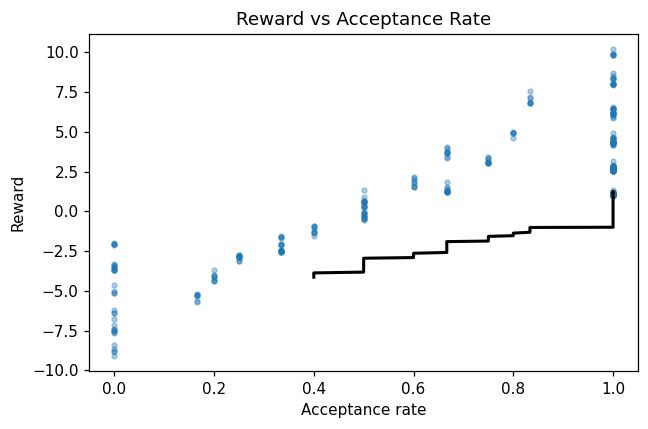

In [22]:
plt.figure(figsize=(6, 4))
plt.scatter(df["acceptance_rate"], df["reward"], s=10, alpha=0.35)
trend = rolling_mean(df.sort_values("acceptance_rate")["reward"], window=400)
plt.plot(np.sort(df["acceptance_rate"]), trend, color="black", linewidth=2)
plt.title("Reward vs Acceptance Rate")
plt.xlabel("Acceptance rate")
plt.ylabel("Reward")
plt.tight_layout()
plt.show()

**Interpretation:** Expect an upward trend. A flat or negative trend suggests acceptance is not sufficiently rewarded.

### B. Reward vs system load

Question: Is load meaningfully penalized?

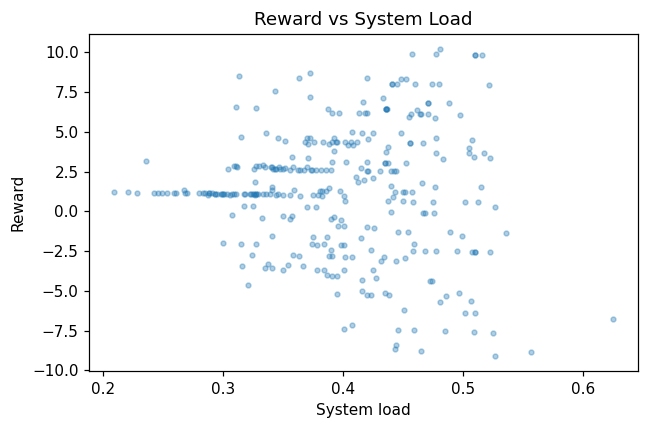

In [23]:
plt.figure(figsize=(6, 4))
plt.scatter(df["system_load"], df["reward"], s=10, alpha=0.35)
plt.title("Reward vs System Load")
plt.xlabel("System load")
plt.ylabel("Reward")
plt.tight_layout()
plt.show()

### C. Reward vs chosen k (Critical)

Question: Does the environment globally favor shallow depths?

<Figure size 660x440 with 0 Axes>

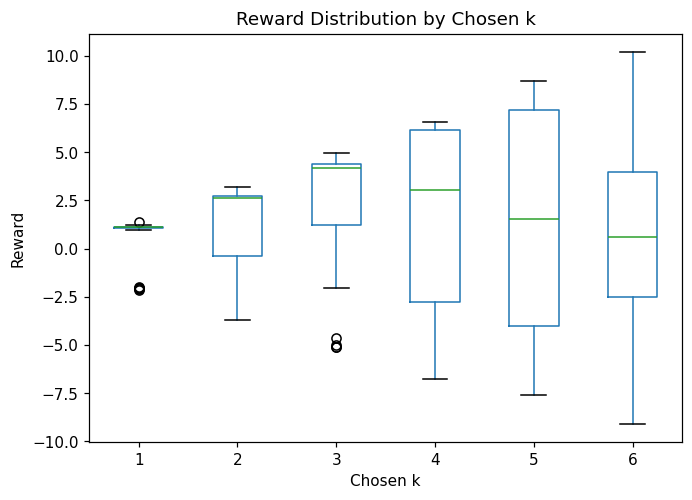

In [24]:
plt.figure(figsize=(6, 4))
df.boxplot(column="reward", by="action", grid=False)
plt.title("Reward Distribution by Chosen k")
plt.suptitle("")
plt.xlabel("Chosen k")
plt.ylabel("Reward")
plt.tight_layout()
plt.show()

### D. Reward decomposition (Important)

Question: Which reward terms dominate?

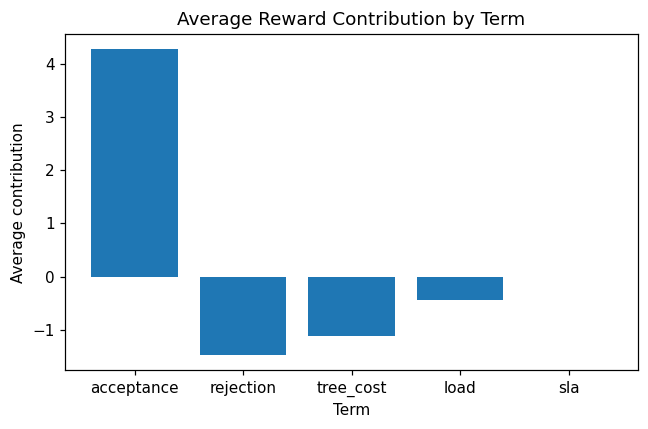

acceptance    4.268750
sla           0.000000
load         -0.437242
tree_cost    -1.116202
rejection    -1.474688
dtype: float64

In [25]:
# Reward components based on LLMTreeSpeculativeDecodingEnv.step
acceptance_contrib = 2.00 * df["accepted_tokens"]
rejection_penalty = -1.10 * df["rejected_depth"]
tree_cost_penalty = -0.35 * df["normalized_tree_cost"]
load_penalty = -0.80 * (1.35 * df["system_load"] + 0.08 * df["queue_length"])
sla_risk = np.maximum(0.0, (60.0 - df["sla_slack_ms"]) / 60.0)
sla_penalty = -0.90 * sla_risk

contrib_df = pd.DataFrame({
    "acceptance": acceptance_contrib,
    "rejection": rejection_penalty,
    "tree_cost": tree_cost_penalty,
    "load": load_penalty,
    "sla": sla_penalty,
})
avg_contrib = contrib_df.mean()

plt.figure(figsize=(6, 4))
plt.bar(avg_contrib.index, avg_contrib.values)
plt.title("Average Reward Contribution by Term")
plt.xlabel("Term")
plt.ylabel("Average contribution")
plt.tight_layout()
plt.show()

avg_contrib.sort_values(ascending=False)

## 3. Simulator regime validation

These plots check whether the simulator actually visits diverse regimes.

### A. Distribution of system load

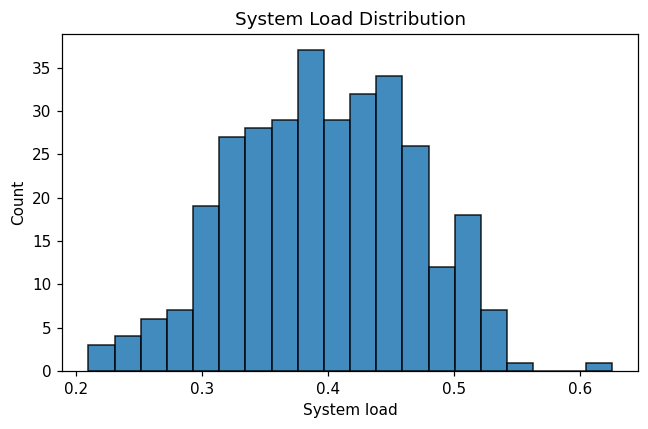

In [26]:
plt.figure(figsize=(6, 4))
plt.hist(df["system_load"], bins=20, edgecolor="black", alpha=0.85)
plt.title("System Load Distribution")
plt.xlabel("System load")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### B. Distribution of queue bucket

Question: Is queue pressure meaningful or almost always zero?

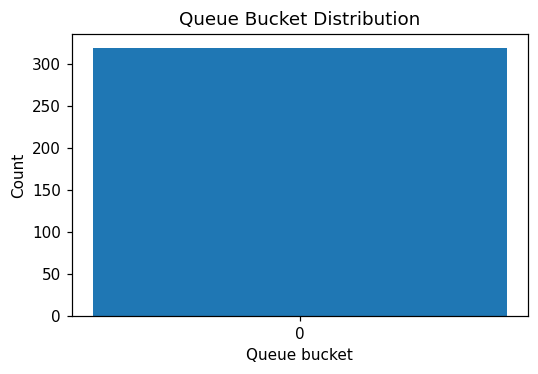

In [27]:
queue_counts = df["queue_bucket"].value_counts().sort_index()
plt.figure(figsize=(5, 3.5))
plt.bar(queue_counts.index.astype(str), queue_counts.values)
plt.title("Queue Bucket Distribution")
plt.xlabel("Queue bucket")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### C. Distribution of acceptance rate

Question: Are high-acceptance states common enough for deep speculation to matter?

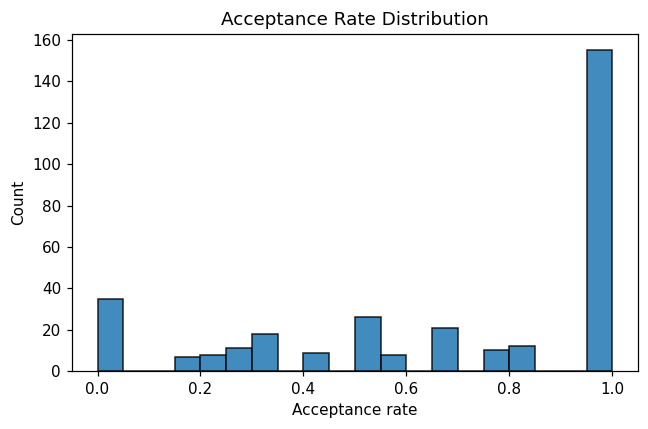

In [28]:
plt.figure(figsize=(6, 4))
plt.hist(df["acceptance_rate"], bins=20, edgecolor="black", alpha=0.85)
plt.title("Acceptance Rate Distribution")
plt.xlabel("Acceptance rate")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### D. Distribution of chosen k

Question: Is the learned policy collapsed to one action?

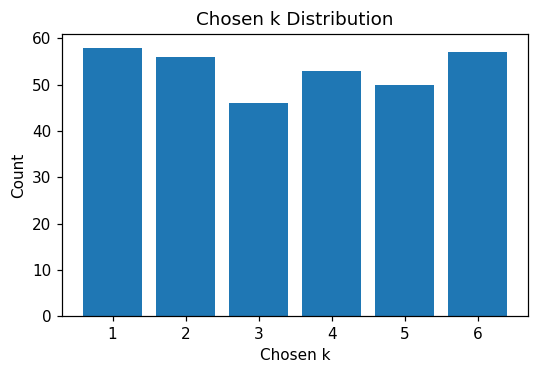

In [29]:
action_counts = df["action"].value_counts().sort_index()
plt.figure(figsize=(5, 3.5))
plt.bar(action_counts.index.astype(str), action_counts.values)
plt.title("Chosen k Distribution")
plt.xlabel("Chosen k")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 4. Feature influence sanity checks

We only check whether three buckets correlate with chosen k.

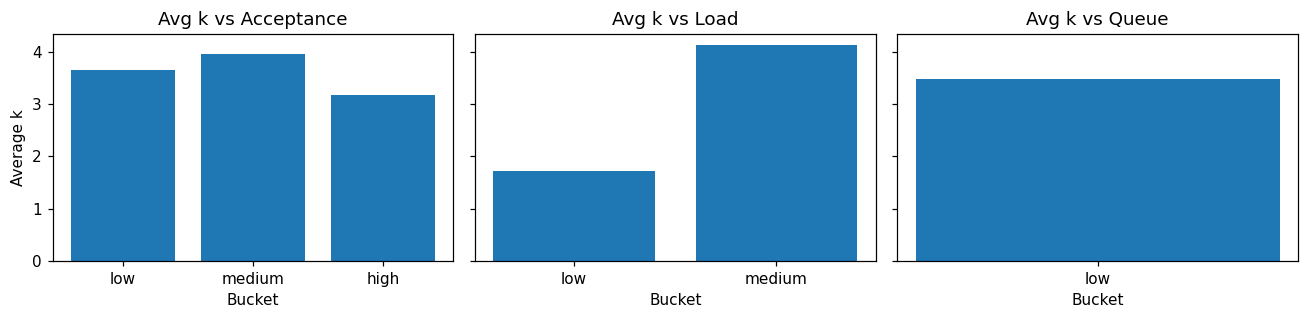

In [30]:
bucket_labels = {0: "low", 1: "medium", 2: "high"}

avg_by_acceptance = df.groupby("acceptance_bucket")["action"].mean()
avg_by_load = df.groupby("load_bucket")["action"].mean()
avg_by_queue = df.groupby("queue_bucket")["action"].mean()

fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)

axes[0].bar([bucket_labels[i] for i in avg_by_acceptance.index], avg_by_acceptance.values)
axes[0].set_title("Avg k vs Acceptance")

axes[1].bar([bucket_labels[i] for i in avg_by_load.index], avg_by_load.values)
axes[1].set_title("Avg k vs Load")

axes[2].bar([bucket_labels[i] for i in avg_by_queue.index], avg_by_queue.values)
axes[2].set_title("Avg k vs Queue")

for ax in axes:
    ax.set_xlabel("Bucket")
axes[0].set_ylabel("Average k")

plt.tight_layout()
plt.show()

## 5. Simple state occupancy diagnostics

These plots detect dead or underused buckets.

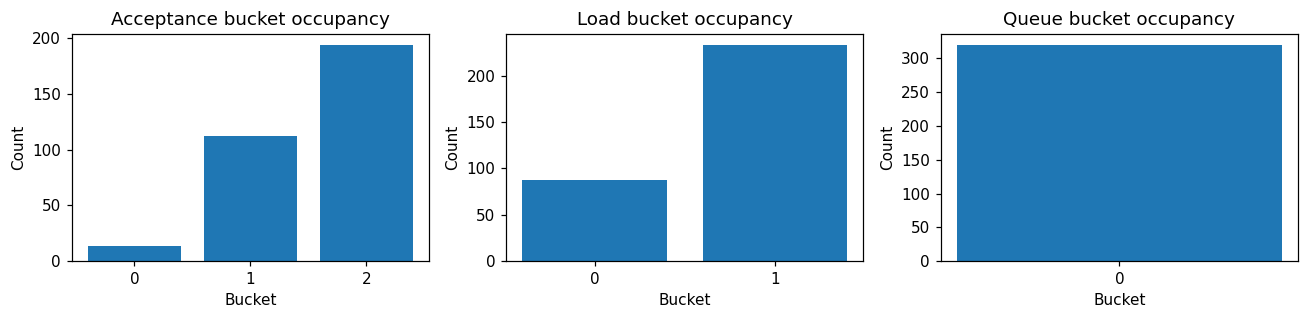

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

for ax, col, title in [
    (axes[0], "acceptance_bucket", "Acceptance bucket occupancy"),
    (axes[1], "load_bucket", "Load bucket occupancy"),
    (axes[2], "queue_bucket", "Queue bucket occupancy"),
]:
    counts = df[col].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values)
    ax.set_title(title)
    ax.set_xlabel("Bucket")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

## 6. Final conclusions

This summary is intentionally cautious and empirical.

In [32]:
from IPython.display import Markdown, display

action_counts = df["action"].value_counts().sort_index()
dominant_share = float(action_counts.max() / action_counts.sum())

avg_k_by_action = df.groupby("action")["reward"].mean()
shallow_favored = avg_k_by_action.idxmax() == avg_k_by_action.index.min()

regime_diversity = {
    "load": df["load_bucket"].nunique(),
    "queue": df["queue_bucket"].nunique(),
    "acceptance": df["acceptance_bucket"].nunique(),
}

influence = {
    "acceptance": float(avg_by_acceptance.max() - avg_by_acceptance.min()),
    "load": float(avg_by_load.max() - avg_by_load.min()),
    "queue": float(avg_by_queue.max() - avg_by_queue.min()),
}
most_influential = max(influence, key=influence.get)

summary_lines = [
    f"- Dominant action share: {dominant_share:.2f} (higher suggests collapse)",
    f"- Shallow k appears best on average: {shallow_favored}",
    f"- Regime diversity (unique buckets): {regime_diversity}",
    f"- Most influential feature by avg-k spread: {most_influential}",
    f"- If reward terms are dominated by a penalty, consider rebalancing before deeper RL changes.",
    f"- These are diagnostic signals only; they do not prove causality.",
]

display(Markdown("### Diagnostic Summary"))
display(Markdown("\n".join(summary_lines)))

### Diagnostic Summary

- Dominant action share: 0.18 (higher suggests collapse)
- Shallow k appears best on average: False
- Regime diversity (unique buckets): {'load': 2, 'queue': 1, 'acceptance': 3}
- Most influential feature by avg-k spread: load
- If reward terms are dominated by a penalty, consider rebalancing before deeper RL changes.
- These are diagnostic signals only; they do not prove causality.